### Multi-Label Classification

In [61]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
# 주피터 노트북에서 그림을 주피터 노트북 내에 표시하도록 강제하는 명령어
%matplotlib inline 

#### torchvision.datasets.MNIST

- torchvision.datasets에 다양한 datasets 이 있음
- MNIST dataset (숫자 필기체)
    - 60,000 training 이미지, 10,000 test 이미지 (28 pixels X 28 pixels)

In [62]:
train_rawdata = datasets.MNIST(root='dataset', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root='dataset', train=False, download=True, transform=transforms.ToTensor())

print('number of training data : ', len(train_rawdata))
print('number of test data : ', len(test_dataset))

number of training data :  60000
number of test data :  10000


#### Validation dataset 분리 (train dataset의 일부를 활용) 

In [63]:
# index 번호만 추출
train_indices, val_indices, _ , _ = train_test_split(range(len(train_rawdata)), # x index 번호
                                              train_rawdata.targets, # y
                                              stratify=train_rawdata.targets, # y를 균등 분포
                                              test_size=0.2)

train_indices[:10]  # train index 번호 10개만 출력

[6489, 3563, 44804, 13796, 36010, 57383, 44589, 18155, 15515, 51477]

### torch.utils.data.Subset 으로 Validation dataset 생성

- torch.utils.data.Subset(데이터, 인덱스번호 리스트)로 인덱스 번호 리스트로 구성된 sub dataset 생성 가능


In [64]:
train_dataset = Subset(train_rawdata, train_indices)
validation_dataset = Subset(train_rawdata, val_indices)

#### dataset size 확인

- 일반적으로는 Train 6, Validation 2, Test 2 (6:2:2)
- 단, 준비된 데이터 사이즈에 따라, 적절히 유사하게 적용

In [65]:
print(len(train_dataset), len(validation_dataset), len(test_dataset))

48000 12000 10000


#### Mini-batch 생성

- 모델 학습시, 매 epoch 마다 데이터를 랜덤으로 섞어서 미니배치(minibatch) 로 구성하여, 학습
- 이를 손쉽게 할 수 있도록, torch.utils.data.DataLoader 제공
- torch.utils.data.DataLoader 데이터셋, batchsize=미니배치사이즈, shuffle=True)
    - shuffle=True 는 랜덤으로 섞는 옵션

> 이미지 데이터만 이므로, feature 값들에 대한 StandardScaler() 를 적용할 필요는 없음

In [66]:
BATCH_SIZE = 128

train_batches = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_batches = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_batches = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False) # 테스트 배치는 번호를 섞지 않는다.
# shuffle : 데이터를 섞을지 여부 (True or False)

In [67]:
X_train, y_train = next(iter(train_batches))
print(X_train.shape, y_train.shape)

torch.Size([128, 1, 28, 28]) torch.Size([128])


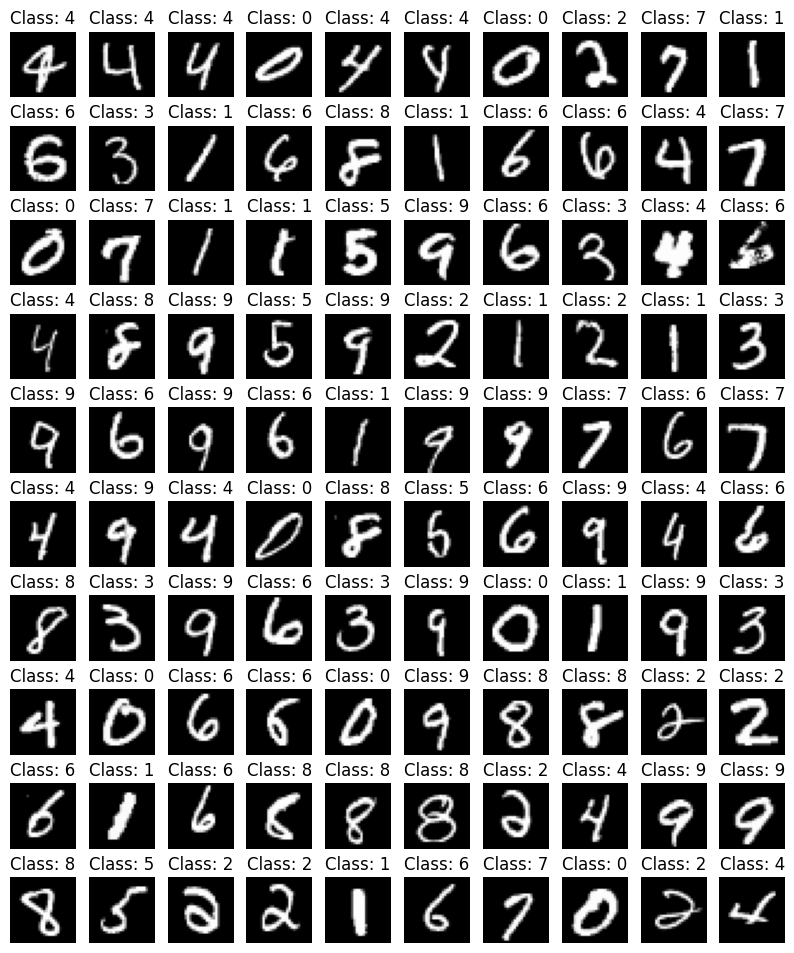

In [68]:
plt.figure(figsize=(10, 12))

X_train, y_train = next(iter(train_batches)) # 미니 배치에서 하나의 데이터만 추출
for index in range(100):
    plt.subplot(10, 10, index + 1)
    plt.axis('off') # x축, y축에 대한 옵션 설정, 축과 라벨을 표시하지 않음
    plt.imshow(X_train[index, :, :, :].squeeze().numpy(), cmap='gray') # 가독성과 안정성 높은 방식
    # plt.imshow(X_train[index, :, :, :].numpy().reshape(28, 28), cmap='gray')
    
    plt.title('Class: ' + str(y_train[index].item()))
    

In [69]:
print(X_train[index, :, :, :].numpy().reshape(28, 28).shape) # (28, 28) 으로 reshape 로 변환
print(X_train[index, :, :, :].squeeze().numpy().shape) # squeeze() 차원이 1인 것을 제거

(28, 28)
(28, 28)


#### 모델 정의

In [70]:
X_train, y_train = next(iter(train_batches))

print(X_train.shape, y_train.shape) # (1, 28, 28) 데이터가 128개 (배치 크기)
print(X_train.size(0))
print(X_train.view(X_train.size(0), -1).shape) #  view() 형태를 바꾼다.

torch.Size([128, 1, 28, 28]) torch.Size([128])
128
torch.Size([128, 784])


In [71]:
class FunModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
    
        self.linear_layers = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0,1),
            nn.Linear(256, 256),
            nn.LeakyReLU(0,1),
            nn.Linear(256, 128),
            nn.LeakyReLU(0,1),
            nn.Linear(128, output_dim),
            nn.Softmax(dim=-1)
        )
        
    def forward(self, x):
        y = self.linear_layers(x)
        return y
    
minibatch_size = 128 # 미니 배치 크기 설정
input_dim = 28 * 28 # 784
output_dim = 10 
model = FunModel(input_dim, output_dim)

loss_func = nn.CrossEntropyLoss() # log softmax는 NLLLoss() 로 진행해야 함
optimizer = torch.optim.Adam(params=model.parameters())

In [72]:
for param in model.parameters():
    print(param)

Parameter containing:
tensor([[ 0.0281,  0.0039,  0.0220,  ..., -0.0322, -0.0221,  0.0063],
        [ 0.0114,  0.0148,  0.0268,  ...,  0.0136,  0.0015,  0.0077],
        [ 0.0352, -0.0315,  0.0157,  ..., -0.0225,  0.0344, -0.0090],
        ...,
        [ 0.0338,  0.0241, -0.0141,  ..., -0.0255, -0.0008,  0.0260],
        [ 0.0094,  0.0211, -0.0035,  ..., -0.0016, -0.0021,  0.0137],
        [-0.0110, -0.0295,  0.0002,  ..., -0.0281, -0.0025,  0.0171]],
       requires_grad=True)
Parameter containing:
tensor([-0.0124,  0.0257,  0.0078,  0.0056, -0.0056,  0.0078, -0.0325,  0.0247,
         0.0169,  0.0077, -0.0175, -0.0242,  0.0154, -0.0117, -0.0089,  0.0159,
        -0.0010,  0.0128, -0.0046, -0.0244,  0.0211, -0.0353,  0.0117, -0.0184,
        -0.0101, -0.0322, -0.0256, -0.0083, -0.0334,  0.0331,  0.0191, -0.0248,
         0.0155, -0.0210,  0.0253,  0.0074, -0.0068, -0.0197, -0.0343,  0.0286,
         0.0023, -0.0351, -0.0180, -0.0047, -0.0126, -0.0077,  0.0015,  0.0087,
        -0.0012

#### 베스트 모델 저장

- 모델의 학습 가능한 매개변수(예, 가중치 편향)들은 모델의 매개변수에 포함되어 있습니다.
    - model.parameters() 로 확인 가능
    - model.stat_dict() 로 각 계층의 모든 매개변수를 사전 객체로 추출 가능 (베스트 모델을 추출하기 위해 활용)
    - model.load_state_dict(x) 로 model.stat_dict() 을 통해 저장된 매개변수(x)를 가져올 수 있음

In [73]:
from copy import deepcopy # 깊은 복사 가능

#### Training Code 템플릿

- model : DNN 모델
- early_stop : Early Stopping  을 위해, 얼마의 epoch 까지 validation set에 대한 loss 가 낮아지지 않을 경우, Early Stopping 을 할지의 하이퍼 파라미터 값
- nb_epochs : 최대 epoch
- progress_interval : 진행상황을 얼마의 epoch 마다 출력할지의 epoch 값

#### model.train()과 model.eval() 기반 Validation Set 테스트

- training set 으로 학습시킬 때는 model.train() 을 호출하고,
- validation set 으로 테스트할 때는 model.eval()과 torch.no_grad() 를 호출함
     - 가중치 업데이트등의 학습을 적용하지 않고, 테스트만 진행함

> test set으로 테스트할 때에도 model.eval()과 torch.no_grad() 호출 필요

#### 이미지 각 픽셀을 feature 로 적용 (1차원으로 변형)

- x_minibatch.size(0) : 128
- x_minibatch.shape : [128, 1, 28, 28]
- x_minibatch.view(x_minibatch.size(0), -1).shape : [128, 784]

- model : DNN 모델
- early_stop : Early Stopping을 위해, 얼마의 epoch 까지 validation set에 대한 loss가 낮아지지 않을 경우, Early Stopping을 할지의 하이퍼 파라미터 값
- nb_epochs: 최대 epoch
- process_interval: 진행 상황을 얼마의 epoch 마다 출력할지의 epoch 값

In [74]:
def train_model(model, early_stop, n_epochs, process_interval):
    
    train_losses, valid_losses, lowest_loss = list(), list(), np.inf # 초기화
    
    for epoch in range(n_epochs):
        
        train_loss, valid_loss = 0, 0 # 각각의 학습 데이터, 검증 데이터의 loss를 구하기 위해 0으로 초기화 해줍니다.
        
        # --- Train ---
        model.train() # 모델 학습
        for x_minibatch, y_minibatch in train_batches:      
            y_minibatch_pred = model(x_minibatch.view(x_minibatch.size(0), -1))
            loss = loss_func(y_minibatch_pred, y_minibatch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item() # 텐서의 실제 값은 .item() 으로 구합니다.
    
        train_loss = train_loss / len(train_batches) # 해당 epoch의 평균 loss 값
        train_losses.append(train_loss)
    
        # validate the model
        model.eval()
        with torch.no_grad(): # 검증 데이터 셋에는 오차 역전파를 하지 않는다.
            for x_minibatch, y_minibatch in val_batches:
                y_minibatch_pred = model(x_minibatch.view(x_minibatch.size(0), -1))
                loss = loss_func(y_minibatch_pred, y_minibatch)
                valid_loss += loss.item()
                
        valid_loss = valid_loss / len(val_batches)
        valid_losses.append(valid_loss) # 평균 loss 값을 마지막에 추가합니다.
                        
        if valid_losses[-1] < lowest_loss:
            lowest_loss = valid_losses[-1]
            lowest_epoch = epoch
            best_model = deepcopy(model.state_dict()) # 모델의 가중치 값을 깊은 복사로 저장
        else:
            if (early_stop > 0) and lowest_epoch + early_stop < epoch:
                print('Early Stopped',epoch,"epochs")
                break   
            
        if(epoch % process_interval) == 0:
            print(train_losses[-1], valid_losses[-1], lowest_loss, lowest_epoch, epoch)

    model.load_state_dict(best_model)
    return model, lowest_loss, train_losses, valid_losses
            

In [75]:
nb_epochs = 30
progress_interval = 3
early_stop = 10

model, lowest_loss, train_losses, valid_losses = train_model(model, early_stop, nb_epochs, progress_interval)

1.6781099096934 1.5552891074342932 1.5552891074342932 0 0
1.5025539258321126 1.501985732545244 1.501985732545244 3 3
1.4894456265767415 1.496336301590534 1.496336301590534 6 6
1.4854766314824421 1.4924126559115471 1.4924126559115471 9 9
1.4812900966008504 1.4897759886498148 1.4897759886498148 12 12
1.4794409872690837 1.491899976070891 1.4897759886498148 12 15
1.477500065167745 1.486386518529121 1.486386518529121 18 18
1.4763572591145833 1.4900500203700775 1.486386518529121 18 21
1.4745040454864502 1.4901697483468563 1.486386518529121 18 24
1.4741267283757529 1.4919670858281724 1.486386518529121 18 27
Early Stopped 29 epochs


In [76]:
valid_losses

[1.5552891074342932,
 1.5264502408656668,
 1.5170042666983097,
 1.501985732545244,
 1.5031588952592079,
 1.5039400597836108,
 1.496336301590534,
 1.5015387636549928,
 1.4958857056942392,
 1.4924126559115471,
 1.4937343673503145,
 1.4930809964524938,
 1.4897759886498148,
 1.4911301998381918,
 1.4902771521121898,
 1.491899976070891,
 1.494686616227982,
 1.496692955493927,
 1.486386518529121,
 1.4880031169729029,
 1.4900507939622758,
 1.4900500203700775,
 1.486689845298199,
 1.4881167183531092,
 1.4901697483468563,
 1.4894770282380125,
 1.493012268492516,
 1.4919670858281724,
 1.489078275700833,
 1.4890247596071122]

#### 텐서 비교

- torch.ne
- torch.eq
- torch.ge
- torch.le
- torch.equal

In [77]:
# element-wise 비교
print(torch.ne(torch.tensor([[1,3],[2, 5]]), torch.tensor([[1,2],[2,4]])))
print(torch.eq(torch.tensor([[1,3],[2, 5]]), torch.tensor([[1,3],[2,5]])))
print(torch.ge(torch.tensor([[1,3],[2, 5]]), torch.tensor([[1,2],[2,4]])))
print(torch.le(torch.tensor([[1,3],[2, 5]]), torch.tensor([[1,2],[2,4]])))
print(torch.equal(torch.tensor([[1,3],[2, 5]]), torch.tensor([[1,2],[2,4]])))

tensor([[False,  True],
        [False,  True]])
tensor([[True, True],
        [True, True]])
tensor([[True, True],
        [True, True]])
tensor([[ True, False],
        [ True, False]])
False


In [78]:
x_minibatch, y_minibatch = next(iter(test_batches))
y_test_pred = model(x_minibatch.view(x_minibatch.size(0), -1))
pred = torch.argmax(y_test_pred, dim=1)
print(y_test_pred.shape, y_minibatch.shape, pred.shape)
correct = pred.eq(y_minibatch).sum()
print(pred.eq(y_minibatch).sum(), pred.eq(y_minibatch).sum().item())

torch.Size([128, 10]) torch.Size([128]) torch.Size([128])
tensor(125) 125


#### 텐서객체.nonzero()
- 0이 아닌 값을 가진 인덱스 번호를 2차원 텐서로 리턴
- 본래는 각 행에서의 0이 아닌 값을 가진 인덱스 번호를 리턴하는 구조

In [79]:
torch.tensor([[0.6, 0.0, 0.0, 0.0],
              [0.0, 0.0, 0.8, 0.0],
             [0.0, 0.9, 0.0, 0.0],
             [0.0, 0.0, 0.0, 0.2]]).nonzero()

tensor([[0, 0],
        [1, 2],
        [2, 1],
        [3, 3]])

In [80]:
torch.tensor([1, 1, 1, 0, 1]).nonzero()

tensor([[0],
        [1],
        [2],
        [4]])

In [81]:
correct.nonzero()

tensor([], size=(1, 0), dtype=torch.int64)

In [83]:
len(test_batches.dataset) # 전체 테스트 데이터 수

10000

In [89]:
print(pred.ne(y_minibatch).shape, pred.ne(y_minibatch), pred.ne(y_minibatch).nonzero()[:,0])
print(pred.ne(y_minibatch).nonzero()[:,0].numpy().tolist()) # index 번호를 리스트로 변환

torch.Size([128]) tensor([False, False, False, False, False, False, False, False,  True, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False,  True, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, Fal

In [90]:
wrong_idx = pred.ne(y_minibatch).nonzero()[:,0].numpy().tolist()
for idx in wrong_idx:
    print(idx)

8
33
92


In [93]:
test_loss = 0
correct = 0
wrong_samples, wrong_preds, actual_preds = list(), list(), list()

model.eval() # 모델 평가 모드로 전환
with torch.no_grad(): # 검증 데이터 셋에는 오차 역전파를 하지 않는다.
    for x_minibatch, y_minibatch in test_batches:
        y_test_pred = model(x_minibatch.view(x_minibatch.size(0), -1))
        test_loss += loss_func(y_test_pred, y_minibatch)
        pred = torch.argmax(y_test_pred, dim=1)
        correct += pred.eq(y_minibatch).sum().item()
        
        wrong_idx = pred.ne(y_minibatch).nonzero()[:,0].numpy().tolist()
        for idx in wrong_idx: # 틀린 샘플들에 대해서만 저장
            wrong_samples.append(x_minibatch[idx]) # 이미지 데이터
            wrong_preds.append(pred[idx]) # 모델이 예측한 값
            actual_preds.append(y_minibatch[idx]) # 실제 값

test_loss = test_loss / len(test_batches)
print('Average Test Loss:', test_loss)
print('Accuracy: {}/{} ({:.2f}%)\n'.format(correct, len(test_batches.dataset), 100. * correct / len(test_batches.dataset)))

Average Test Loss: tensor(1.4855)
Accuracy: 9750/10000 (97.50%)



**incorrect data 만 확인해보기**

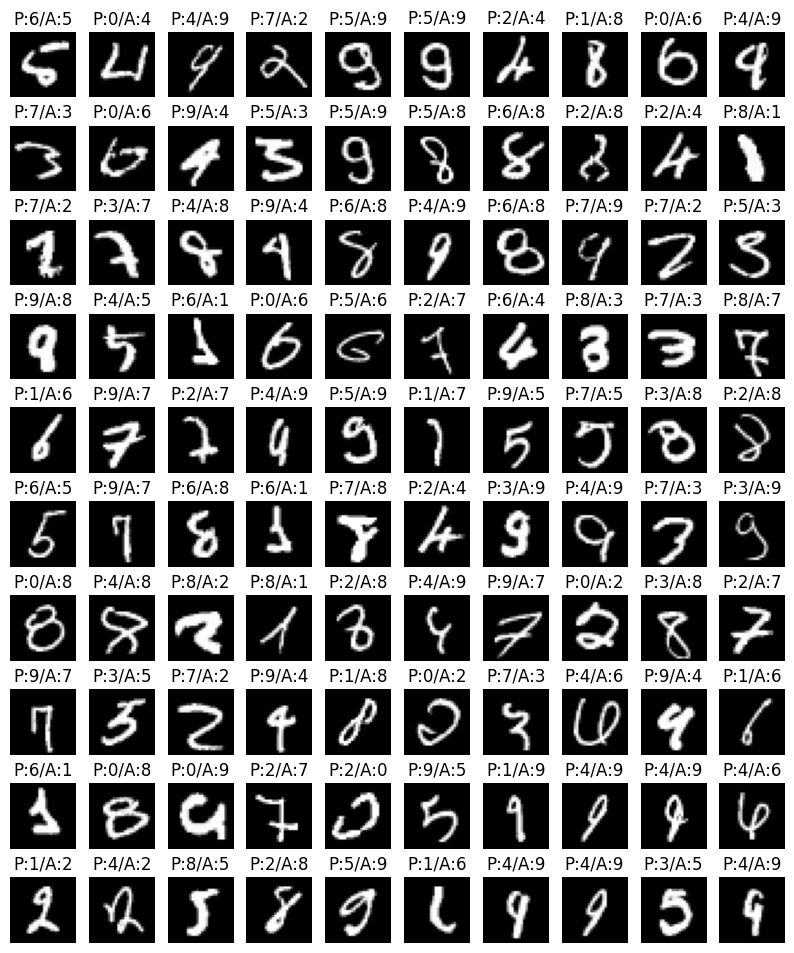

In [98]:
plt.figure(figsize=(10, 12))
for i in range(100):
    plt.subplot(10, 10, i + 1)
    plt.axis('off') # x축, y축에 대한 옵션 설정, 축과 라벨을 표시하지 않음
    plt.imshow(wrong_samples[i].squeeze().numpy(), cmap='gray') # 가독성과 안정성 높은 방식
    plt.title('P:' + str(wrong_preds[i].item()) + '/A:' + str(actual_preds[i].item()))